# 2.1 Grossman-Miller Market Making Model

Two types of market participants:

- Outside Customers (OC) / Liquidity Traders (LT)
- Market Makers (MM)

Classical assumption: any quantity of an asset can be bought or sold at "the price". But then:

- Why are there bid-ask spreads?
- Why do large trades move prices?
- Why do MMs earn money on average?
- Liquidity has a cost because of imperfect risk sharing across time

## Three timestamps
$t = 1$: "liquidity event". LT1 arrives to trade $i$ units of a risky asset. Non-economic reason (not trading on information).

$t = 2$: a second outside customer LT2 wants to take the other side (trade $-i$). LT1 has already traded by then, so LT2 actually trades with the MMs.

$t = 3$: asset pays its final cash value:

$$S_3 = \mu + \epsilon_2 + \epsilon_3$$

- $\mu$ is the known fundamental value, what everyone expects the asset to be worth
- $\epsilon_2$ and $\epsilon_3$ are random news shocks affecting the final value
  - each drawn from a normal distribution with mean 0 and variance $\sigma^2$
  - mean 0 means the news is unbiased: as likely to push the price up as down
  - $\sigma^2$ controls how big each one-period shock typically is
- $\epsilon_2$ is revealed between $t=1$ and $t=2$ (so known at $t=2$, unknown at $t=1$)
- $\epsilon_3$ is revealed between $t=2$ and $t=3$ (so known only at $t=3$)
- "independent" means knowing $\epsilon_2$ tells you nothing about $\epsilon_3$, no autocorrelation in the news
- unconditionally, $\mathrm{Var}(S_3) = \mathrm{Var}(\epsilon_2 + \epsilon_3) = 2\sigma^2$
- the equilibrium discount below uses the one-period risk $\sigma^2$ that MMs bear between $t=1$ and $t=2$

Other model assumptions:

- LT2 is not available at $t = 1$. Buyer and seller are not present at the same time
- Initial holdings: MMs hold 0, LT1 holds $i$, LT2 holds $-i$, all start with cash $W_0$
- No trading costs, no inventory holding costs

## Market Makers as intermediaries

MMs are risk-averse with **Constant Absolute Risk Aversion (CARA)** utility:

$$U(X) = -\exp(-\gamma X), \quad \gamma > 0$$

### What CARA means

- $\gamma$ is the **coefficient of absolute risk aversion**. Bigger $\gamma$ means more risk-averse
- "Constant" means $\gamma$ does not change with wealth
  - concretely: a \$1k coin flip feels the same to a \$10k agent and a \$1M agent
  - unrealistic (people usually fear losses less when wealthier), but tractable: asset demand ends up depending only on prices and variance, not wealth
- This is what makes the equilibrium solvable in closed form

### Certainty equivalent

- The **certainty equivalent** $\text{CE}(X)$ is the guaranteed cash amount an agent would accept in exchange for a risky payoff $X$
- If a coin flip pays \$0 or \$100, expected value is \$50, but a risk-averse agent might accept \$40 for sure rather than play. Then $\text{CE} = 40$
- The gap between expected value and certainty equivalent is the **risk premium**: the discount the agent charges for bearing risk
- Risk-neutral: $\text{CE} = \mathbb{E}[X]$. Risk-averse: $\text{CE} < \mathbb{E}[X]$

### The CARA + normal formula

For a normally distributed one-period risky payoff $X$ with $\mathbb{E}[X] = \mu$ and $\mathrm{Var}(X) = \sigma^2$:

- When $X$ is normally distributed with variance $\sigma^2$ and the agent has CARA utility:

$$\text{CE}(X) = \mu - \tfrac{1}{2}\gamma \sigma^2$$

- Maximising expected utility is equivalent to maximising this certainty equivalent
- This is the workhorse for every model in the chapter: an agent values a risky position at its expected value minus a penalty proportional to risk aversion and variance
- All agents (MMs and LTs) are CARA risk-averse with the same $\gamma$

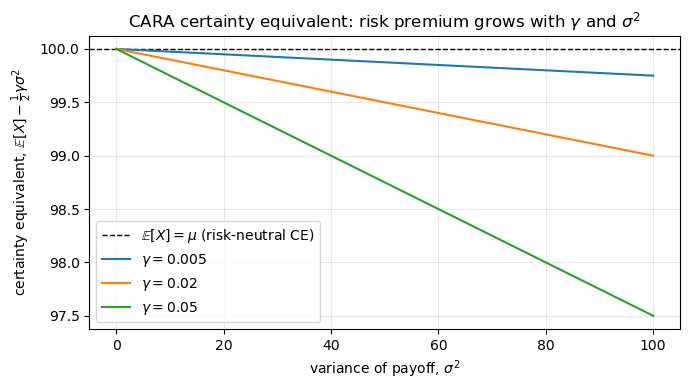

In [27]:
import numpy as np; import matplotlib.pyplot as plt
mu = 100                              # expected value of the payoff
variances = np.linspace(0, 100, 200)  # x-axis: variance of the payoff
gammas = [0.005, 0.02, 0.05]          # three levels of risk aversion
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(mu, color="k", ls="--", lw=1, label=r"$\mathbb{E}[X]=\mu$ (risk-neutral CE)")
for g in gammas:
    ce = mu - 0.5 * g * variances
    ax.plot(variances, ce, label=fr"$\gamma = {g}$")
ax.set_xlabel(r"variance of payoff, $\sigma^2$")
ax.set_ylabel(r"certainty equivalent, $\mathbb{E}[X] - \frac{1}{2}\gamma \sigma^2$")
ax.set_title(r"CARA certainty equivalent: risk premium grows with $\gamma$ and $\sigma^2$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Reading the plot:

- The dashed line at $\mu$ is what a risk-neutral agent would accept (no discount for risk)
- Each downward-sloping line is a risk-averse agent's CE as variance grows
- The gap between the dashed line and a CARA line at any $\sigma^2$ is the **risk premium** that agent demands
- Steeper line = more risk-averse ($\gamma$ larger) = bigger premium for the same variance
- This is exactly the discount that becomes the **liquidity premium** $\gamma\sigma^2 \tfrac{i}{n+1}$ in the equilibrium price below: the MM's CE penalty translates directly into how far below $\mu$ they will buy from LT1

## MMs point of view
$t = 1$: $n$ MMs and LT1 are present (LT2 not yet). MMs absorb part of LT1's position. Each holds $\frac{i}{n+1}$ shares whose payoff is uncertain. They bear unwanted risk until $t = 2$.

$t = 2$: LT2 arrives. Now $n + 2$ risk-averse agents share the original $i$ units. The market clears (LT1 and LT2's needs offset), so the price equals the fundamental and everyone exits with zero inventory.

$t = 3$: each agent collects $S_3$ per share they hold.

- MMs are risk-averse, holding $\frac{i}{n+1}$ units of random payoff hurts their utility. They will only absorb shares if compensated, i.e. at a price below the expected fundamental value. This is the **liquidity premium**
- LT1 is also risk-averse, so he doesn't dump all $i$ units at $t=1$. He keeps $\frac{i}{n+1}$ and sells the rest, because parting with shares at a discount is also costly


## Equilibrium price
Under CARA + normal payoffs, each agent's optimal holding is **linear in price**:

$$q_t^{j,*} = \frac{\mathbb{E}[S_3 \mid \epsilon_2] - S_t}{\gamma \sigma^2}$$

At $t = 1$ no shock is known yet, so $\mathbb{E}[S_3] = \mu$. At $t = 2$ the shock $\epsilon_2$ is revealed, so $\mathbb{E}[S_3 \mid \epsilon_2] = \mu + \epsilon_2$.

**At $t = 2$**: all $n+2$ agents share the same demand. Market clearing gives $S_2 = \mu + \epsilon_2$, and $q_2^{j,*} = 0$ for everyone.

**At $t = 1$**: only $n$ MMs and LT1 are present. Each has the same linear demand. Market clearing requires total holdings equal $i$ (LT1's initial position):

$$i = (n+1) \cdot \frac{\mu - S_1}{\gamma \sigma^2}$$

Solving:

$$\boxed{\ S_1 = \mu - \gamma \sigma^2 \frac{i}{n+1}\ }$$

- the $n+1$ comes from $n$ MMs $+$ LT1 sharing the risk at $t=1$
- each ends up holding $\frac{i}{n+1}$ units of the asset
- for $i > 0$ (LT1 sells), MMs absorb at a **discount** below $\mu$
- for $i < 0$ (LT1 buys), MMs sell at a **premium** above $\mu$

### Interpretation:
$$S_1 = \mu - \gamma \sigma^2 \frac{i}{n+1}$$

- $\mu$: expected value of $S_3$, the fundamental price
- $\gamma$: MMs' risk aversion. More risk-averse MMs charge more
- $\sigma^2$: one-period inventory risk. Riskier assets are more expensive to make markets in
- $i$: size of the liquidity demand. Bigger trades pay a bigger premium, price impact is linear in size
- $n+1$: depth of the market. More MMs sharing the risk means a tighter premium
- as $n \to \infty$ the premium vanishes, $S_1 \to \mu$, LT1 trades the full $i$ at the efficient price


### This shows
- liquidity is not free and not infinite
- price impact scales with size and risk
- market depth depends on the risk-bearing capacity of the MMs
- spreads exist without information asymmetry, the premium arises purely from intertemporal risk-bearing. Adverse selection (Glosten-Milgrom, Kyle) is a separate layer
- LT1 also splits his trade across periods, this is the seed of optimal execution

## Example: LT1 sells 1000 GameStop (GME) shares
Parameters (only on the order of magnitude, not actual quotes):
- $\mu = \$25$ (expected terminal value per share)
- $\sigma = \$5$ per share, so $\sigma^2 = 25$ (per-period variance of news shocks $\epsilon_t$)
- $\gamma = 0.001$ per dollar (CARA risk aversion, same for everyone)
- $n = 4$ market makers
- $i = 1000$ shares (LT1 holds them and wants to sell)
- initial cash for everyone: $W_0 = \$50{,}000$

LT2 will arrive at $t=2$ wanting to buy 1000 shares ($-i$).

In [28]:
mu, sigma, gamma, n, i, W0 = 25, 5, 0.001, 4, 1000, 50_000

discount       = gamma * sigma**2 * i / (n + 1)
S1             = mu - discount
q_each         = i / (n + 1)
lt1_sells_at_1 = i - q_each

print(f"liquidity discount   = ${discount:.2f}")
print(f"S_1                  = ${S1:.2f}")
print(f"inventory per agent  = {q_each:.0f} shares")
print(f"LT1 sells at t=1     = {lt1_sells_at_1:.0f} shares")

liquidity discount   = $5.00
S_1                  = $20.00
inventory per agent  = 200 shares
LT1 sells at t=1     = 800 shares


### State at the end of t = 1

| Agent | Shares | Cash |
|---|---|---|
| Each MM (×4) | +200 | $50{,}000 - 200 \cdot 20 = \$46{,}000$ |
| LT1 | $1000 - 800 = 200$ | $50{,}000 + 800 \cdot 20 = \$66{,}000$ |
| LT2 (not yet present) | $-1000$ | $\$50{,}000$ |

The equilibrium condition is that the **marginal share** is fairly priced for every present agent. The certainty equivalent of buying $q$ shares at $S_1$ and bearing inventory risk until $t=2$ is $q\mu - \tfrac{1}{2}\gamma q^2 \sigma^2 - q S_1$, and the optimum sets its derivative to zero:

$$\frac{d}{dq}\left[q\mu - \tfrac{1}{2}\gamma q^2 \sigma^2 - q S_1\right] = \mu - \gamma q \sigma^2 - S_1 = 0$$

Plugging in $q = 200$: $25 - 0.001 \cdot 200 \cdot 25 - 20 = 0$. The marginal share is worth exactly $S_1$ to every agent, which is why nobody wants to trade further.

In [29]:
# assuming epsilon_2 = 0, the t=2 price equals the fundamental
S2 = mu
mm_gain_t2 = q_each * (S2 - S1)

print(f"S_2                 = ${S2}")
print(f"each MM sells       = {q_each:.0f} shares, gain ${mm_gain_t2:,.2f}")
print(f"LT1 sells remaining = {q_each:.0f} shares at ${S2}")
print(f"LT2 buys            = 1000 shares at ${S2}, paying ${1000*S2:,}")

S_2                 = $25
each MM sells       = 200 shares, gain $1,000.00
LT1 sells remaining = 200 shares at $25
LT2 buys            = 1000 shares at $25, paying $25,000


### State at the end of t = 2

All inventory clears (LT1's original 1000 shares end up with LT2):

| Agent | Shares | Cash | Wealth vs. start (at fundamental \$25) |
|---|---|---|---|
| Each MM | 0 | $46{,}000 + 200 \cdot 25 = \$51{,}000$ | $+\$1{,}000$ |
| LT1 | 0 | $66{,}000 + 200 \cdot 25 = \$71{,}000$ | $-\$4{,}000$ |
| LT2 | 0 (started at -1000) | $50{,}000 - 25{,}000 = \$25{,}000$ | $0$ |

P&L is computed against initial wealth at the fundamental price: each MM started with \$50,000 (cash only), LT1 with \$75,000 (cash + 1000 shares × \$25), LT2 with \$25,000 (cash − 1000 shares × \$25). Total P&L sums to zero.

**Where the MMs' profit comes from:** each MM bought 200 shares at \$20 at $t=1$ and sold at \$25 at $t=2$, earning $200 \cdot \$5 = \$1{,}000$. Across 4 MMs that's \$4,000.

**Where LT1's loss comes from:** LT1 sold 800 shares at the discount price of \$20 at $t=1$ instead of the fundamental \$25, losing $800 \cdot \$5 = \$4{,}000$. The remaining 200 shares cleared at fundamental at $t=2$, so the entire loss is from the $t=1$ sale.

**This is the liquidity premium in action:** LT1 paid \$4,000 to the MMs in exchange for not having to wait until $t=2$. The MMs earned \$4,000 for bearing price risk between $t=1$ and $t=2$. LT2 broke even because they arrived when the market was balanced and traded at fundamental.

### Comparison

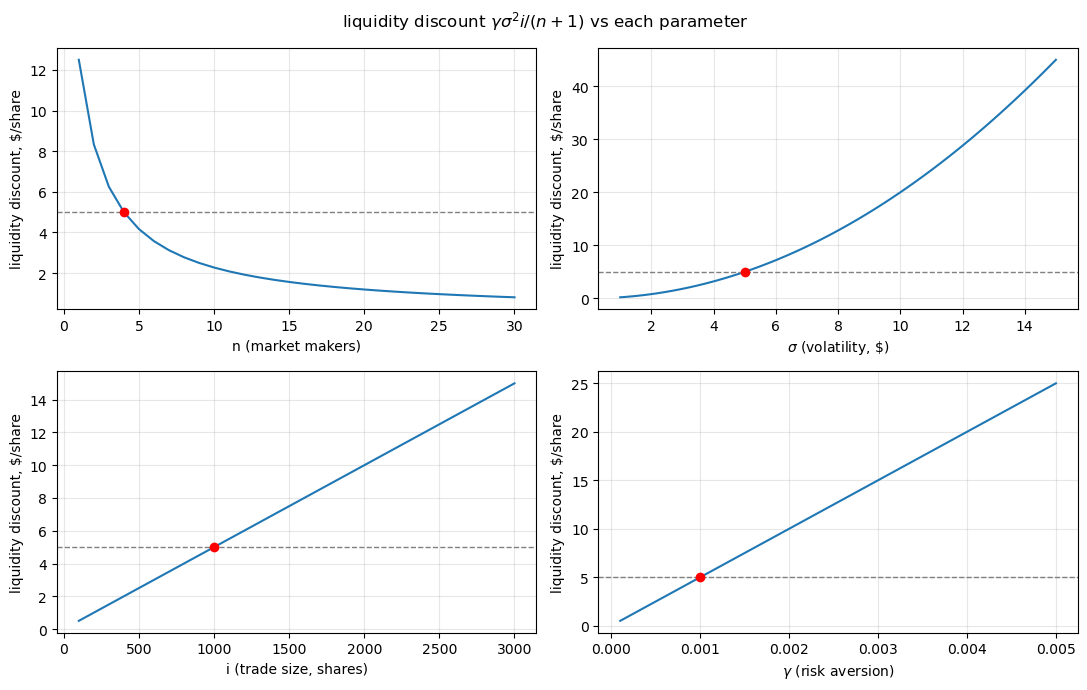

In [30]:
import numpy as np; import matplotlib.pyplot as plt
base = dict(mu=25, sigma=5, gamma=0.001, n=4, i=1000)
disc = lambda mu, sigma, gamma, n, i: gamma * sigma**2 * i / (n + 1)
d0 = disc(**base)
sweeps = [
    ("n (market makers)",         "n",     np.arange(1, 31)),
    (r"$\sigma$ (volatility, \$)", "sigma", np.linspace(1, 15, 100)),
    ("i (trade size, shares)",    "i",     np.linspace(100, 3000, 100)),
    (r"$\gamma$ (risk aversion)", "gamma", np.linspace(0.0001, 0.005, 100)),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (label, key, xs) in zip(axes.flat, sweeps):
    ax.plot(xs, [disc(**{**base, key: x}) for x in xs])
    ax.scatter(base[key], d0, color="red", zorder=5)
    ax.axhline(d0, ls="--", color="grey", lw=1)
    ax.set(xlabel=label, ylabel="liquidity discount, \$/share")
    ax.grid(alpha=0.3)
fig.suptitle(r"liquidity discount $\gamma \sigma^2 i / (n+1)$ vs each parameter")
plt.tight_layout(); plt.show()

- more competition $\to$ smaller discount (linear in $1/(n+1)$)
- more volatility $\to$ much larger discount (quadratic in $\sigma$, since $\sigma^2$)
- larger trade $\to$ larger discount (linear in $i$)
- more risk-averse MMs $\to$ larger discount (linear in $\gamma$)

In the limit $n \to \infty$ the discount vanishes: with infinitely many MMs sharing
the risk, LT1 trades the full 1000 shares at the fundamental price.

### When the discount makes prices negative
The formula has no upper bound. At high enough $\sigma$ the equation gives
$S_1 < 0$: LT1 pays the MMs to take the shares. This is not a model artefact
like during coronavirus lockdowns when oil futures went negative due to storage constraints.
**WTI May 2020 futures settled at -\$37/bbl**: holders faced physical
delivery with no storage and paid buyers to take the contracts.

# Trading Costs
Extend Grossman-Miller with a per-share trading fee $\eta$ (eta) paid by every trader on every share they trade (both sides). Assume any inventory remaining at $t=2$ is liquidated at $t=3$ (so even holding through pays a fee eventually).

### Demands at $t=1$

LT1 sells at $t=1$ (effective receipt $S_1 - \eta$) so his remaining inventory after trading is:

$$q_1^{LT1}(S_1) = \frac{\mu - S_1}{\gamma \sigma^2}$$

The $\eta$'s cancel: LT1 is selling now or later. He pays the same fee both times.

MMs buy at $t=1$ (effective cost $S_1 + \eta$), and also anticipate selling at $t=2$ (effective receipt $S_2 - \eta$):

$$q_1^{MM}(S_1) = \frac{\mu - S_1 - 2\eta}{\gamma \sigma^2}$$

The $2\eta$ is the round-trip fee: MMs pay once to buy, once to sell.

### Market clearing at $t=1$

Total shares held equal LT1's initial $i$:

$$n q_1^{MM}(S_1) + q_1^{LT1}(S_1) = i$$

Substitute the two demand functions:

$$n \cdot \frac{\mu - S_1 - 2\eta}{\gamma \sigma^2} + \frac{\mu - S_1}{\gamma \sigma^2} = i$$

Solving:

$$\boxed{\ S_1 = \mu - \gamma \sigma^2 \frac{i}{n+1} - \frac{2n}{n+1}\eta\ }$$

Two discounts now: the original risk-based one, and a new fee-based one of $\frac{2n}{n+1}\eta$.

At this clearing price, the equilibrium inventories are:

$$q_1^{LT1,*} = \frac{i}{n+1} + \frac{2n\eta}{(n+1)\gamma\sigma^2}$$

$$q_1^{MM,*} = \frac{i}{n+1} - \frac{2\eta}{(n+1)\gamma\sigma^2}$$

So trading fees make LT1 sell slightly less immediately, and each MM carries slightly less inventory.

The model treats quantities as continuous, so these inventories can be fractional. For real stocks, trades would be rounded to whole shares.

In [31]:
def S1(mu=25, sigma=5, gamma=0.001, n=4, i=1000, eta=0):
    risk_disc = gamma * sigma**2 * i / (n + 1)
    fee_disc  = 2 * n / (n + 1) * eta
    return mu - risk_disc - fee_disc, risk_disc, fee_disc

for eta in [0, 0.01, 0.05, 0.10]:
    s, rd, fd = S1(eta=eta)
    print(f"eta=${eta:.2f}:  S_1=${s:.3f}  risk discount=${rd:.2f}  fee discount=${fd:.4f}")

eta=$0.00:  S_1=$20.000  risk discount=$5.00  fee discount=$0.0000
eta=$0.01:  S_1=$19.984  risk discount=$5.00  fee discount=$0.0160
eta=$0.05:  S_1=$19.920  risk discount=$5.00  fee discount=$0.0800
eta=$0.10:  S_1=$19.840  risk discount=$5.00  fee discount=$0.1600


### Who pays the fees?

Every share traded costs $\eta$ on each side, but cost is split differently between LT and MM:

- LT1 pays $\eta$ explicitly on his own trade
- LT1 also pays $\frac{2n}{n+1}\eta$ implicitly through a worse $S_1$
- each MM pays $2\eta$ round-trip ($\eta$ buying at $t=1$, $\eta$ selling at $t=2$)
- each MM recovers $\frac{2n}{n+1}\eta$ per share through the wider discount
- each MM nets $\frac{2}{n+1}\eta$ in unrecovered fees
- MM competition forces them to bake their own fees into $S_1$, so the liquidity demander bears most of the cost


### What does this mean for MMs?
Per MM, the trade earns a risk-premium profit and pays an unrecovered fee cost:
- shares traded per MM: $q_1^{MM,*} = \frac{i}{n+1} - \frac{2\eta}{(n+1)\gamma\sigma^2}$
- expected risk profit per share: $\gamma \sigma^2 \frac{i}{n+1}$ (MM buys at $S_1$, resells at $S_2 = \mu$ since $\mathbb{E}[\epsilon_2] = 0$)
- unrecovered fee per share: $\frac{2}{n+1}\eta$
- net expected profit per MM: $q_1^{MM,*}$ times (risk profit per share minus fee cost per share)
- in any one realisation an MM can lose money if $\epsilon_2$ is large. The model says they break even on risk in expectation and earn the discount as compensation

In [32]:
def mm_per_share(mu=25, sigma=5, gamma=0.001, n=4, i=1000, eta=0.003):
    shares      = i / (n + 1) - 2 * eta / ((n + 1) * gamma * sigma**2)
    risk_disc   = gamma * sigma**2 * i / (n + 1)
    fee_unrecov = 2 * eta / (n + 1)
    risk_profit = shares * risk_disc
    fee_cost    = shares * fee_unrecov
    return shares, risk_profit, fee_cost, risk_profit - fee_cost

print(f"{'n':>3} {'shares/MM':>10} {'risk profit':>14} {'fee cost':>10} {'net':>12}")
for n in [1, 4, 20]:
    shares, rp, fc, net = mm_per_share(n=n)
    print(f"{n:>3} {shares:>10.2f} {rp:>14.2f} {fc:>10.4f} {net:>12.2f}")

  n  shares/MM    risk profit   fee cost          net
  1     499.88        6248.50     1.4996      6247.00
  4     199.95         999.76     0.2399       999.52
 20      47.61          56.68     0.0136        56.66


With $i = 1000$, $\sigma = 5$, $\gamma = 0.001$, $\eta = \$0.003$:

- **shares/MM**: $\frac{i}{n+1} - \frac{2\eta}{(n+1)\gamma\sigma^2}$, inventory each MM carries
- **risk profit**: shares $\times \gamma \sigma^2 \frac{i}{n+1}$, earned for bearing inventory risk
- **fee cost**: shares $\times \frac{2\eta}{n+1}$, unrecovered after pass-through
- **net**: risk profit minus fee cost

- risk profit per MM falls quadratically in $n$: fewer shares and smaller discount, both $\propto \frac{1}{n+1}$
- fee cost per MM is negligible at realistic exchange fees
- net per MM: $\$6247 \to \$1000 \to \$57$ as $n$ goes 1 → 4 → 20
- competition crushes MMs through the risk channel

# Measuring Liquidity

The Grossman-Miller equilibrium gives a price that deviates from the fundamental.
Two ways to turn that into a measurable quantity from real data: **price impact** and the **autocovariance of price changes**.

### Price impact
Reinterpret the Walrasian auction as an electronic market:
- LT1 sends market orders that walk the LOB, eating resting limit orders posted by MMs.
- The price moves as he trades, and he stops once it has moved too far.
- He has sold $q^{LT1} = \frac{n}{n+1}i$ shares at an average price $S_1$.

Equilibrium price is now linear in the quantity actually traded:

$$S_1 = \mu + \lambda \, q^{LT1}$$

Matching against $S_1 = \mu - \gamma\sigma^2 \frac{i}{n+1}$ with $q^{LT1} = i\frac{n}{n+1}$:

$$\lambda = -\frac{1}{n}\gamma \sigma^2, \qquad q^{LT1} = i\frac{n}{n+1}$$

- $q^{LT1} > 0$ means shares sold by LT1
- $\lambda$ is the **price impact**: the price moves by $\lambda$ per share sold
- $\lambda$ is negative here, so selling more shares pushes the price down
- it comes from MM inventory risk
- a more liquid market has $\lambda$ closer to zero (smaller in magnitude): more competition (higher $n$), lower risk aversion (lower $\gamma$), or lower volatility (lower $\sigma^2$)


The plot shows $S_1 = \mu + \lambda q^{LT1}$ for three values of $n$.
Each line shows the average execution price LT1 receives as a function of how many shares he sells (in a market with $n$ MMs).

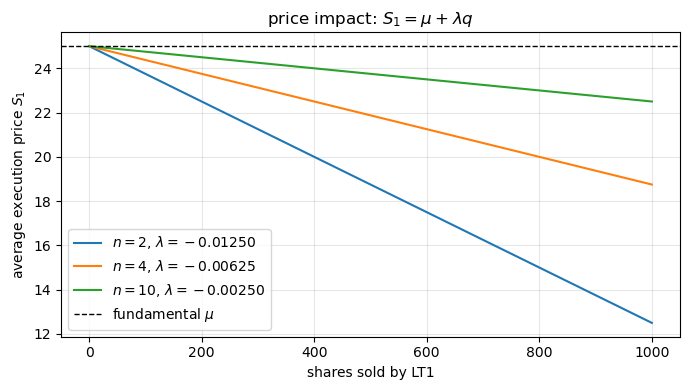

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu, sigma, gamma = 25, 5, 0.001
shares_sold = np.linspace(0, 1000, 200)

fig, ax = plt.subplots(figsize=(7, 4))
for n in [2, 4, 10]:
    lam = -(gamma * sigma**2 / n)
    ax.plot(shares_sold, mu + lam * shares_sold, label=fr"$n={n}$, $\lambda={lam:.5f}$")
ax.axhline(mu, color="k", ls="--", lw=1, label=r"fundamental $\mu$")
ax.set_xlabel("shares sold by LT1")
ax.set_ylabel("average execution price $S_1$")
ax.set_title(r"price impact: $S_1 = \mu + \lambda q$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- each line starts at $\mu = \$25$ when no shares are sold
- selling more shares pushes the average price down, the line slopes away from $\mu$
- the slope is $\lambda = -\gamma\sigma^2/n$: steeper means less liquid
- $n=2$ (two MMs) has the steepest line, $n=10$ the flattest: more competition absorbs the order with less price movement

**The more shares LT1 sells the "deeper" he walks the book. The first shares execute near $\mu$, while later shares execute lower. The slope depends on the market's $\lambda$: competition, risk aversion, and volatility.**

### Autocovariance of price changes
A second measure looks at how the price *moves over time* in comparison to the number of shares sold.
To set it up, add a date $t=0$ before LT1 arrives, and a public news shock $\epsilon_1$ revealed between $t=0$ and $t=1$. The final value is now:

$$S_3 = \mu + \epsilon_1 + \epsilon_2 + \epsilon_3$$

with $\epsilon_1, \epsilon_2, \epsilon_3$ i.i.d. normal, mean 0, variance $\sigma^2$.

##### Recall: martingale
- a **martingale** is a process whose expected next value equals its current value: $\mathbb{E}[\mu_{t+1} \mid \text{info at } t] = \mu_t$
- it has no predictable drift: the best forecast of tomorrow is today's value
- here the **efficient price** $\mu_t$ is the running expectation of $S_3$ given the news revealed so far
  - $\mu_0 = \mu$, $\mu_1 = \mu + \epsilon_1$, $\mu_2 = \mu + \epsilon_1 + \epsilon_2$
  - each step adds one mean-zero shock, so $\mathbb{E}[\mu_{t+1} \mid \text{info at } t] = \mu_t$
- a martingale price is what you would see in a market with no frictions: it is not predictable and only moves on genuine news

##### The equilibrium prices, with the trade only at $t=1$:
- $S_0 = \mu_0$ (no trade yet)
- $S_1 = \mu_1 + \lambda q^{LT1}$ (LT1's order moves the observed price away from the efficient price)
- $S_2 = \mu_2$ (market is balanced again, price returns to efficient)

Here $\lambda = -\frac{1}{n}\gamma\sigma^2$ is negative and $q^{LT1} = i\frac{n}{n+1}$ is positive, so $\lambda q^{LT1} < 0$ and the price sits below the efficient price.

##### Recall: covariance and autocovariance
- **covariance** measures whether two quantities move together: $\mathrm{Cov}[A, B] = \mathbb{E}[(A - \mathbb{E}A)(B - \mathbb{E}B)]$
  - positive: they tend to move in the same direction
  - negative: when one is up the other tends to be down
  - zero: no linear relationship
- key rules used below:
  - independent quantities have zero covariance
  - $\mathrm{Cov}[A, A] = \mathrm{Var}[A]$
  - covariance is linear: $\mathrm{Cov}[A + c, B + d] = \mathrm{Cov}[A, B]$ for constants, and scalars pull out
- **autocovariance** is the covariance of a time series with its own lagged values: here, between one price change and the next

##### Define the two consecutive price changes:
$$\Delta_1 = S_1 - S_0 = \epsilon_1 + \lambda q^{LT1}$$
$$\Delta_2 = S_2 - S_1 = \epsilon_2 - \lambda q^{LT1}$$

Across many liquidity events, the order size $q^{LT1}$ varies. The $\epsilon$'s are independent of each other and of $q^{LT1}$, so they drop out of the covariance, leaving only the shared $\lambda q^{LT1}$ term with opposite signs:

$$\mathrm{Cov}[\Delta_1, \Delta_2] = -\lambda^2 \, \mathrm{Var}[q^{LT1}] < 0$$

- price changes are **negatively autocorrelated**
- LT1's order moves the price at $t=1$, then it reverts to the efficient price at $t=2$
- this reversion pattern is a **temporary-impact bounce**
- as liquidity improves ($\lambda \to 0$) the autocovariance vanishes and the observed price converges to the efficient martingale $\mu_t$


**A trade does not change the asset's worth. It only moves the price because a risk-averse market maker demands a discount to hold unwanted inventory. Once that inventory passes to the natural buyer the discount disappears and the price returns to fundamental. The move was temporary compensation. How strongly consecutive moves pull against each other measures the size of these knocks, the market's liquidity.**

#### One episode
The plot below shows the mechanism for a single liquidity event. LT1 sells $q$ shares at $t=1$. With no news this episode, the efficient price stays flat at $\mu$, but the observed price moves:

- $S_0 = \mu$: no trade yet, price at fundamental
- $S_1 = \mu + \lambda q$: the order moves the price by the impact $\lambda q$
- $S_2 = \mu$: the market is balanced again, price returns to fundamental

In [34]:
import numpy as np; import matplotlib.pyplot as plt
mu, sigma, gamma, n, i = 25, 5, 0.001, 4, 1000
lam = -(gamma * sigma**2 / n)  # book convention: lambda is negative
q = n / (n + 1) * i            # LT1 sells, so q is positive shares sold
S0 = mu
S1 = mu + lam * q
S2 = mu
d1 = S1 - S0                   # price change from t=0 to t=1
d2 = S2 - S1                   # price change from t=1 to t=2
print(f"lambda = {lam:.5f}, shares sold q = {q:.0f}")
print(f"S0 = {S0:.3f}")
print(f"S1 = {S1:.3f}  (down by lambda*q = {lam*q:.3f})")
print(f"S2 = {S2:.3f}  (back to fundamental)")
print(f"d1 = {d1:.3f}  (price change t0->t1)")
print(f"d2 = {d2:.3f}  (price change t1->t2)")

lambda = -0.00625, shares sold q = 800
S0 = 25.000
S1 = 20.000  (down by lambda*q = -5.000)
S2 = 25.000  (back to fundamental)
d1 = -5.000  (price change t0->t1)
d2 = 5.000  (price change t1->t2)


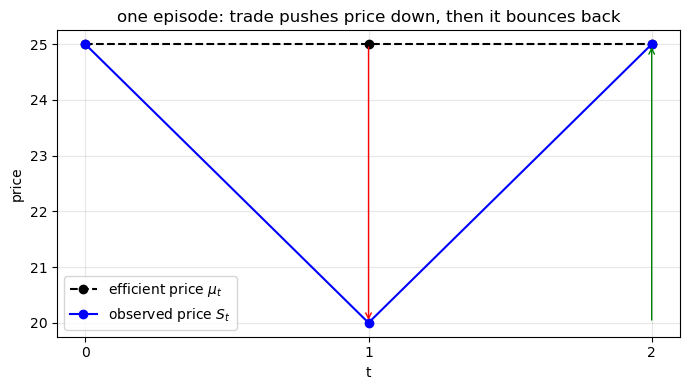

In [35]:
t = [0, 1, 2]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, [mu, mu, mu], "k--", marker="o", label=r"efficient price $\mu_t$")
ax.plot(t, [S0, S1, S2], "b-", marker="o", label=r"observed price $S_t$")
ax.annotate("", xy=(1, S1), xytext=(1, S0), arrowprops=dict(arrowstyle="->", color="red"))
ax.annotate("", xy=(2, S2), xytext=(2, S1), arrowprops=dict(arrowstyle="->", color="green"))
ax.set_xticks(t)
ax.set_xlabel("t")
ax.set_ylabel("price")
ax.set_title("one episode: trade pushes price down, then it bounces back")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- $\Delta_1$ is negative (red arrow down): LT1's sell at $t=1$ pushes the price below fundamental
- $\Delta_2$ is positive (green arrow up): the price recovers to fundamental at $t=2$
- one down-move followed by one up-move: this is the **bounce**
- in this no-news episode the two changes have opposite signs by construction.
- With news, one episode may not reverse exactly, but across many events with varying order sizes the temporary impact term creates a measurable negative covariance